# Reward Ablation Study: SAC-Based Gamma Controller
## Membandingkan Pure Return vs Sharpe vs Sortino vs Differential Sharpe

**Tujuan:** Mengevaluasi dampak pemilihan **fungsi reward** terhadap performa portofolio,
diukur dengan metrik evaluasi yang seragam: **CAGR, Max Drawdown, dan Sharpe Ratio (test)**.

---

## Desain Eksperimen

| ID | Reward Function | Formula | Referensi |
|----|----------------|---------|-----------|
| R0 | **Pure Return** | `port_ret × 100` | Baseline |
| R1 | **Rolling Sharpe** | `mean(ret) × √252 / std(ret)` | Sharpe (1966) |
| R2 | **Rolling Sortino** | `mean(ret) × 252 / downside_std` | Sortino & Price (1994) |
| R3 | **Differential Sharpe** | Incremental Sharpe via Moody & Saffell | Moody & Saffell (2001) |

> **Catatan:** Semua eksperimen menggunakan fitur yang **sama** (E0 Baseline: 9 fitur),
> hanya fungsi reward yang berbeda. Backtest dievaluasi dengan metrik identik agar perbandingan adil.


## Setup & Install

In [1]:
#%pip install stable_baselines3[extra]

In [2]:
# ================================================================
# GLOBAL SETTINGS
# ================================================================
SEEDS         = [42, 123, 77]
TRAIN_STEPS   = 1000
GAMMA_CENTER  = 1.0
SET_WINDOW    = 30
SET_REBALANCE = 7
REWARD_WINDOW = 20   # rolling window untuk Sharpe & Sortino

# Fitur tetap: E0_Baseline (9 fitur original)
FEATURE_CONFIG = {'use_network': True, 'use_market': True, 'extra_features': []}

# Reward configs — hanya reward yang berbeda
REWARD_CONFIGS = {
    'R0_PureReturn'       : 'pure_return',
    'R1_RollingSharpe'    : 'rolling_sharpe',
    'R2_RollingSortino'   : 'rolling_sortino',
    'R3_DiffSharpe'       : 'diff_sharpe',
}

# Static benchmarks untuk referensi
STATIC_BENCHMARKS = {
    'Comp_Static_Gamma0' : 0.0,
    'Comp_Static_Gamma1' : 1.0,
    'Comp_Static_Gamma2' : 2.0,
}

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
import warnings
import os
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import SAC
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('reward_ablation_results', exist_ok=True)

print('Libraries loaded.')
print(f'Reward configs  : {list(REWARD_CONFIGS.keys())}')
print(f'Feature config  : {FEATURE_CONFIG}')


Libraries loaded.
Reward configs  : ['R0_PureReturn', 'R1_RollingSharpe', 'R2_RollingSortino', 'R3_DiffSharpe']
Feature config  : {'use_network': True, 'use_market': True, 'extra_features': []}


## Phase 1: Data Preparation

In [3]:
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
        print('USDT removed from assets.')
    assets.sort()
    df = df[assets]
    split_idx = int(len(df) * train_split)
    return df.iloc[:split_idx], df.iloc[split_idx:], assets

ret_train, ret_test, assets = load_and_split(file_data)

print(f'Assets ({len(assets)}): {assets}')
print(f'Training : {ret_train.index[0].date()} – {ret_train.index[-1].date()} ({len(ret_train)} days)')
print(f'Testing  : {ret_test.index[0].date()} – {ret_test.index[-1].date()} ({len(ret_test)} days)')


USDT removed from assets.
Assets (9): ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training : 2017-09-15 – 2019-03-02 (534 days)
Testing  : 2019-03-03 – 2019-10-17 (229 days)


## Phase 2: Core Functions (RMT + Markowitz + MST)

In [4]:
def apply_rmt_filter(returns_window):
    """Random Matrix Theory filter untuk denoising matriks korelasi."""
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1 / Q)) ** 2
    n_signal = np.sum(eigenvalues >= lambda_max)
    if n_signal == 0:
        eigenvalues[:-1] = 0
    else:
        eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised


def _solve_weights(cov_f, cent_vec, mu, gamma, n_assets):
    """Solver SLSQP. Fallback ke equal-weight jika infeasible."""
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    bounds = tuple((0, 0.4) for _ in range(n_assets))
    w0 = np.ones(n_assets) / n_assets
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    return res2.x if res2.success else w0


def get_centrality_weights(returns_window, gamma=1.0):
    """Hitung bobot portofolio berbasis centrality MST + Markowitz."""
    T, N = returns_window.shape
    mu    = returns_window.mean().values
    sigma = returns_window.std().values
    corr_f = apply_rmt_filter(returns_window)
    cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except Exception:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return _solve_weights(cov_f, cent_vec, mu, gamma, N)


def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    return _solve_weights(cov_f, cent_vec, mu, gamma, len(mu))


def calculate_total_return(ret_series):
    return (1 + np.array(ret_series)).prod() - 1

def calculate_annualized_return(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    n = len(arr)
    if n == 0: return np.nan
    total = (1 + arr).prod()
    if total <= 0: return np.nan
    return total ** (periods_per_year / n) - 1

def calculate_metrics(returns_series):
    """Hitung semua metrik evaluasi utama."""
    arr = np.array(returns_series)
    n   = len(arr)
    total_ret = (1 + arr).prod() - 1
    ann_ret   = calculate_annualized_return(arr)
    ann_vol   = arr.std() * np.sqrt(252)
    sharpe    = ann_ret / ann_vol if ann_vol > 0 else 0.0
    cumulative = (1 + arr).cumprod()
    peak       = np.maximum.accumulate(cumulative)
    drawdown   = (cumulative - peak) / peak
    max_dd     = drawdown.min()
    calmar     = ann_ret / abs(max_dd) if max_dd != 0 else 0.0
    downside   = arr[arr < 0]
    down_std   = np.std(downside) * np.sqrt(252) if len(downside) > 0 else 0.0
    sortino    = ann_ret / down_std if down_std > 0 else 0.0
    return {
        'Total Return'    : total_ret,
        'Ann. Return'     : ann_ret,
        'Ann. Volatility' : ann_vol,
        'Sharpe Ratio'    : sharpe,
        'Sortino Ratio'   : sortino,
        'Calmar Ratio'    : calmar,
        'Max Drawdown'    : max_dd,
    }

print('Core functions defined.')


Core functions defined.


## Phase 3: Feature Engineering

In [5]:
def compute_network_features(returns_window):
    T, N = returns_window.shape
    corr_f   = apply_rmt_filter(returns_window)
# 1. Network Density (standard undirected: ignore diagonal)
upper_idx = np.triu_indices(N, k=1)
density   = np.sum(np.abs(corr_f[upper_idx]) > 0.1) / (N * (N - 1) / 2) if N > 1 else 0.0
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full   = nx.from_numpy_array(dist_mat)
    mst      = nx.minimum_spanning_tree(G_full)
    mst_dist = sum(d['weight'] for _, _, d in mst.edges(data=True))
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec   = np.array([centrality[i] for i in range(N)])
    except Exception:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return np.array([
        np.std(cent_vec)  * 10,
        np.mean(cent_vec) * 10,
        mst_dist          * 0.1,
        np.max(cent_vec),
        density
    ], dtype=np.float32), corr_f, cent_vec


def compute_market_features(returns_window, port_val=0.0):
    short_ret  = returns_window.iloc[-5:].mean().mean()
    long_ret   = returns_window.mean().mean()
    momentum   = short_ret - long_ret
    recent_vol = returns_window.iloc[-5:].std().mean()
    return np.array([
        short_ret  * 100,
        momentum   * 100,
        recent_vol * 100,
        port_val
    ], dtype=np.float32)


def build_observation(returns_window, port_val=0.0):
    nw_feat, corr_f, cent_vec = compute_network_features(returns_window)
    mkt_feat = compute_market_features(returns_window, port_val)
    obs = np.concatenate([nw_feat, mkt_feat])
    return np.nan_to_num(obs), corr_f, cent_vec


OBS_DIM = 9   # 5 network + 4 market (E0_Baseline fixed)
print(f'Feature Engineering defined. obs_dim = {OBS_DIM}')


Feature Engineering defined. obs_dim = 9


## Phase 4: Precompute Data Cache

In [6]:
def precompute_data(returns_data, window_size=30):
    """Precompute obs, cov, centrality cache — dipakai semua reward configs."""
    obs_cache, opt_cache, baseline_ret_cache = {}, {}, {}
    print(f'  Precomputing {len(returns_data) - window_size} steps...')
    for i in range(window_size, len(returns_data)):
        win = returns_data.iloc[i - window_size : i]
        T, N = win.shape
        obs, corr_f, cent_vec = build_observation(win, port_val=0.0)
        obs_cache[i] = obs
        sigma = win.std().values
        mu    = win.mean().values
        cov_f = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
        opt_cache[i] = (cov_f, cent_vec, mu)
        w_base = fast_centrality_weights(cov_f, cent_vec, mu, gamma=1.0)
        baseline_ret_cache[i] = np.dot(w_base, returns_data.iloc[i].values)
    print(f'  Done! obs_dim={len(obs_cache[window_size])}')
    return obs_cache, opt_cache, baseline_ret_cache

print('Precomputing training data cache...')
train_obs_cache, train_opt_cache, train_baseline_cache = precompute_data(ret_train, SET_WINDOW)
print('Training cache ready.')


Precomputing training data cache...
  Precomputing 504 steps...
  Done! obs_dim=9
Training cache ready.


## Phase 5: Reward Functions — Penjelasan Teoritis

### R0: Pure Return
$$r_t = \text{port\_ret}_t \times 100$$
Reward paling sederhana. Agent belajar memaksimalkan return harian tanpa mempertimbangkan risiko.

---

### R1: Rolling Sharpe Ratio
$$r_t = \frac{\bar{\mu}_W \cdot \sqrt{252}}{\sigma_W + \epsilon}$$
di mana $\bar{\mu}_W$ dan $\sigma_W$ adalah mean dan std return dalam window $W$ hari terakhir.
Agent dihukum untuk setiap volatilitas, baik naik maupun turun.

---

### R2: Rolling Sortino Ratio
$$r_t = \frac{\bar{\mu}_W \cdot 252}{\sigma_{\text{downside},W} + \epsilon}$$
Hanya menghukum **downside volatility** — lebih adil untuk distribusi return kripto yang right-skewed.

---

### R3: Differential Sharpe Ratio (DSR)
$$DSR_t = \frac{B_t \cdot \Delta A_t - \frac{1}{2} A_t \cdot \Delta B_t}{(B_t - A_t^2)^{3/2}}$$
di mana $A_t$ dan $B_t$ adalah running mean return dan running mean return² (update eksponensial).
Dikembangkan oleh Moody & Saffell (2001) — secara teoritis **paling proper** untuk online RL
karena merupakan turunan Sharpe terhadap action terbaru.

> **Referensi:** Moody, J., & Saffell, M. (2001). Learning to trade via direct reinforcement.
> *IEEE Transactions on Neural Networks*, 12(4), 875–889.


## Phase 6: Multi-Reward Environment

In [7]:
class RewardAblationEnv(gym.Env):
    """
    Environment tunggal yang mendukung 4 jenis reward via parameter reward_type.
    Semua reward dinormalisasi Welford agar skala training stabil.

    reward_type options:
        'pure_return'     : port_ret * 100
        'rolling_sharpe'  : Rolling Sharpe (window=REWARD_WINDOW)
        'rolling_sortino' : Rolling Sortino (window=REWARD_WINDOW)
        'diff_sharpe'     : Differential Sharpe Ratio (Moody & Saffell 2001)
    """
    def __init__(self, returns_data, obs_cache, opt_cache,
                 baseline_ret_cache, reward_type='pure_return',
                 window_size=30, gamma_center=1.0,
                 reward_window=20, dsr_eta=0.01):
        super().__init__()
        self.data               = returns_data
        self.obs_cache          = obs_cache
        self.opt_cache          = opt_cache
        self.baseline_ret_cache = baseline_ret_cache
        self.reward_type        = reward_type
        self.window_size        = window_size
        self.gamma_center       = gamma_center
        self.reward_window      = reward_window
        self.dsr_eta            = dsr_eta   # learning rate untuk DSR running stats

        # State
        self.current_step  = window_size
        self.port_val      = 1.0
        self.peak_val      = 1.0

        # Buffer untuk rolling rewards (R1, R2)
        self._ret_buffer   = []

        # Running stats untuk DSR (R3) — Moody & Saffell
        self._dsr_A        = 0.0   # exponential running mean return
        self._dsr_B        = 0.0   # exponential running mean return^2

        # Welford normalisasi
        self._rew_mean  = 0.0
        self._rew_M2    = 0.0
        self._rew_count = 0

        self.action_space      = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf,
                                            shape=(OBS_DIM,), dtype=np.float32)

    # ── Observation ──────────────────────────────────────────────────────────
    def _get_obs(self):
        obs = self.obs_cache[self.current_step].copy()
        # Update port_val di slot F9 (index 8 = offset 5 network + 3 market)
        if len(obs) > 8:
            obs[8] = self.port_val - 1.0
        return obs

    # ── Welford online normalisasi ────────────────────────────────────────────
    def _normalize_reward(self, r):
        self._rew_count += 1
        delta = r - self._rew_mean
        self._rew_mean += delta / self._rew_count
        delta2 = r - self._rew_mean
        self._rew_M2 += delta * delta2
        var = self._rew_M2 / self._rew_count if self._rew_count > 1 else 1.0
        std = max(np.sqrt(var), 1e-6)
        return float(np.clip(r / std, -10.0, 10.0))

    # ── Reward Computations ───────────────────────────────────────────────────
    def _reward_pure_return(self, port_ret):
        """R0: Pure daily return."""
        return port_ret * 100

    def _reward_rolling_sharpe(self, port_ret):
        """R1: Rolling Sharpe Ratio (window = REWARD_WINDOW hari)."""
        self._ret_buffer.append(port_ret)
        if len(self._ret_buffer) > self.reward_window:
            self._ret_buffer.pop(0)
        arr = np.array(self._ret_buffer)
        if len(arr) < 2:
            return port_ret * 100   # fallback awal episode
        mean_r = arr.mean()
        std_r  = arr.std() + 1e-8
        sharpe = mean_r * np.sqrt(252) / std_r
        return float(np.clip(sharpe, -10.0, 10.0))

    def _reward_rolling_sortino(self, port_ret):
        """R2: Rolling Sortino Ratio — hanya menghukum downside volatility."""
        self._ret_buffer.append(port_ret)
        if len(self._ret_buffer) > self.reward_window:
            self._ret_buffer.pop(0)
        arr = np.array(self._ret_buffer)
        if len(arr) < 2:
            return port_ret * 100
        mean_r   = arr.mean()
        downside = arr[arr < 0]
        if len(downside) == 0:
            # Tidak ada return negatif — beri reward proporsional return
            return float(np.clip(mean_r * 252 * 10, -10.0, 10.0))
        down_std = np.std(downside) * np.sqrt(252) + 1e-8
        sortino  = mean_r * 252 / down_std
        return float(np.clip(sortino, -10.0, 10.0))

    def _reward_diff_sharpe(self, port_ret):
        """
        R3: Differential Sharpe Ratio (Moody & Saffell, 2001).
        DSR = (B*dA - 0.5*A*dB) / (B - A^2)^(3/2)
        di mana A, B adalah running mean return dan return^2 (exponential update).
        """
        eta = self.dsr_eta
        A_prev = self._dsr_A
        B_prev = self._dsr_B

        # Exponential update
        self._dsr_A += eta * (port_ret - A_prev)
        self._dsr_B += eta * (port_ret ** 2 - B_prev)

        dA = self._dsr_A - A_prev
        dB = self._dsr_B - B_prev

        K = self._dsr_B - self._dsr_A ** 2
        if K < 1e-8:
            # Variance hampir nol — gunakan return langsung
            return port_ret * 100
        denom = K ** 1.5
        dsr   = (self._dsr_B * dA - 0.5 * self._dsr_A * dB) / denom
        return float(np.clip(dsr * 100, -10.0, 10.0))

    # ── Reset ─────────────────────────────────────────────────────────────────
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step  = self.window_size
        self.port_val      = 1.0
        self.peak_val      = 1.0
        self._ret_buffer   = []
        self._dsr_A        = 0.0
        self._dsr_B        = 0.0
        self._rew_mean     = 0.0
        self._rew_M2       = 0.0
        self._rew_count    = 0
        return self._get_obs(), {}

    # ── Step ──────────────────────────────────────────────────────────────────
    def step(self, action):
        gamma = float(np.clip(action[0], -5.0, 5.0)) + self.gamma_center
        cov_f, cent_vec, mu = self.opt_cache[self.current_step]
        w = fast_centrality_weights(cov_f, cent_vec, mu, gamma)
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)

        self.port_val *= (1 + port_ret)
        self.peak_val  = max(self.peak_val, self.port_val)

        # Pilih reward sesuai tipe
        if self.reward_type == 'pure_return':
            raw_reward = self._reward_pure_return(port_ret)
        elif self.reward_type == 'rolling_sharpe':
            raw_reward = self._reward_rolling_sharpe(port_ret)
        elif self.reward_type == 'rolling_sortino':
            raw_reward = self._reward_rolling_sortino(port_ret)
        elif self.reward_type == 'diff_sharpe':
            raw_reward = self._reward_diff_sharpe(port_ret)
        else:
            raw_reward = port_ret * 100

        reward = self._normalize_reward(raw_reward)

        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        obs  = self._get_obs() if not done else np.zeros(self.observation_space.shape)
        return obs, reward, done, False, {}


print('RewardAblationEnv defined.')
print(f'Supported reward types: {list(REWARD_CONFIGS.values())}')


RewardAblationEnv defined.
Supported reward types: ['pure_return', 'rolling_sharpe', 'rolling_sortino', 'diff_sharpe']


## Phase 7: Strategy & Backtest Engine

In [8]:
class RewardStrategy:
    """SAC strategy untuk reward ablation. Mendukung static benchmark."""
    def __init__(self, name, model_path, reward_type, gamma_center=1.0):
        self.name         = name
        self.reward_type  = reward_type
        self.gamma_center = gamma_center
        self.is_static    = model_path == 'static'
        self.last_gamma   = gamma_center

        if self.is_static:
            self.model = None
        else:
            self.model = SAC.load(model_path)

    def compute_weights(self, returns_window, port_val=1.0):
        if self.is_static:
            return get_centrality_weights(returns_window, gamma=self.last_gamma)
        obs, _, _ = build_observation(returns_window, port_val=port_val - 1.0)
        action, _ = self.model.predict(obs, deterministic=True)
        self.last_gamma = float(np.clip(action[0], -5.0, 5.0)) + self.gamma_center
        return get_centrality_weights(returns_window, gamma=self.last_gamma)


def run_backtest(strategy, data, window=30, rebalance_freq=7):
    """Walk-forward backtest dengan rebalancing periodik."""
    rets, dates, gamma_history = [], [], []
    current_weights = None
    port_val        = 1.0
    for i in range(window, len(data)):
        if (i - window) % rebalance_freq == 0:
            window_df       = data.iloc[i - window : i]
            current_weights = strategy.compute_weights(window_df, port_val=port_val)
            gamma_history.append(strategy.last_gamma)
        if current_weights is not None:
            daily_ret = np.dot(current_weights, data.iloc[i].values)
            port_val  = port_val * (1 + daily_ret)
            rets.append(daily_ret)
            dates.append(data.index[i])
    return (pd.Series(rets, index=dates, name=strategy.name),
            pd.Series(gamma_history))


print('Strategy & Backtest engine defined.')


Strategy & Backtest engine defined.


## Phase 8: Training — Semua Reward Configs × Seeds

Melatih SAC untuk setiap kombinasi **reward_type × seed** menggunakan fitur E0_Baseline.


In [9]:
sac_kwargs = {
    'policy'         : 'MlpPolicy',
    'learning_rate'  : 3e-4,
    'buffer_size'    : 50000,
    'batch_size'     : 256,
    'ent_coef'       : 'auto',
    'train_freq'     : 1,
    'gradient_steps' : 1,
    'learning_starts': 200,
    'tau'            : 0.005,
    'gamma'          : 0.99,
}

trained_model_paths = {}   # {(reward_id, seed): model_path}

sep = '=' * 60
for reward_id, reward_type in REWARD_CONFIGS.items():
    print(f'\n{sep}')
    print(f'Reward Config: {reward_id} | type={reward_type}')

    for seed in SEEDS:
        model_name = f'reward_ablation_{reward_id}_seed{seed}'
        print(f'  Training seed={seed}...')

        env = RewardAblationEnv(
            ret_train, train_obs_cache, train_opt_cache, train_baseline_cache,
            reward_type    = reward_type,
            window_size    = SET_WINDOW,
            gamma_center   = GAMMA_CENTER,
            reward_window  = REWARD_WINDOW,
        )

        model = SAC(env=env, seed=seed, verbose=0, **sac_kwargs)
        model.learn(total_timesteps=TRAIN_STEPS, progress_bar=True)
        model.save(model_name)
        trained_model_paths[(reward_id, seed)] = model_name
        print(f'    Saved: {model_name}.zip')

# Static benchmarks — tidak perlu training
for bench_id, gamma_val in STATIC_BENCHMARKS.items():
    for seed in SEEDS:
        trained_model_paths[(bench_id, seed)] = 'static'

print('\n=== Semua model reward ablation selesai dilatih ===')



Reward Config: R0_PureReturn | type=pure_return
  Training seed=42...


Output()

Output()

    Saved: reward_ablation_R0_PureReturn_seed42.zip
  Training seed=123...


Output()

...

Output()

    Saved: reward_ablation_R3_DiffSharpe_seed42.zip
  Training seed=123...


Output()

    Saved: reward_ablation_R3_DiffSharpe_seed123.zip
  Training seed=77...


    Saved: reward_ablation_R3_DiffSharpe_seed77.zip

=== Semua model reward ablation selesai dilatih ===


## Phase 9: Backtest — Training & Testing

In [10]:
reward_results = {}   # {exp_id: {'train': {seed: series}, 'test': {seed: series}}}

# Backtest reward configs
for reward_id, reward_type in REWARD_CONFIGS.items():
    print(f'\nBacktest: {reward_id}')
    reward_results[reward_id] = {'train': {}, 'test': {}}

    for seed in SEEDS:
        model_path = trained_model_paths[(reward_id, seed)]

        strat_tr = RewardStrategy(f'{reward_id}_s{seed}', model_path, reward_type, GAMMA_CENTER)
        ret_tr, _ = run_backtest(strat_tr, ret_train, SET_WINDOW, SET_REBALANCE)
        reward_results[reward_id]['train'][seed] = ret_tr

        strat_te = RewardStrategy(f'{reward_id}_s{seed}', model_path, reward_type, GAMMA_CENTER)
        ret_te, _ = run_backtest(strat_te, ret_test, SET_WINDOW, SET_REBALANCE)
        reward_results[reward_id]['test'][seed] = ret_te

        print(f'  seed={seed} | Train CAGR: {calculate_annualized_return(ret_tr):.4f}'
              f' | Test CAGR: {calculate_annualized_return(ret_te):.4f}')

# Backtest static benchmarks
for bench_id, gamma_val in STATIC_BENCHMARKS.items():
    print(f'\nBacktest: {bench_id} (gamma={gamma_val})')
    reward_results[bench_id] = {'train': {}, 'test': {}}

    for seed in SEEDS:
        strat = RewardStrategy(bench_id, 'static', 'pure_return', gamma_center=gamma_val)
        strat.last_gamma = gamma_val
        ret_tr, _ = run_backtest(strat, ret_train, SET_WINDOW, SET_REBALANCE)
        reward_results[bench_id]['train'][seed] = ret_tr

        strat2 = RewardStrategy(bench_id, 'static', 'pure_return', gamma_center=gamma_val)
        strat2.last_gamma = gamma_val
        ret_te, _ = run_backtest(strat2, ret_test, SET_WINDOW, SET_REBALANCE)
        reward_results[bench_id]['test'][seed] = ret_te

print('\nSemua backtest selesai.')



Backtest: R0_PureReturn
  seed=42 | Train CAGR: -0.3855 | Test CAGR: -0.0991
  seed=123 | Train CAGR: -0.2723 | Test CAGR: -0.0991
  seed=77 | Train CAGR: -0.3859 | Test CAGR: -0.0991

Backtest: R1_RollingSharpe
  seed=42 | Train CAGR: -0.3943 | Test CAGR: -0.0991
  seed=123 | Train CAGR: -0.3700 | Test CAGR: -0.0991
  seed=77 | Train CAGR: -0.3867 | Test CAGR: -0.0991

Backtest: R2_RollingSortino
  seed=42 | Train CAGR: -0.3846 | Test CAGR: -0.0991
  seed=123 | Train CAGR: -0.3971 | Test CAGR: -0.0991
  seed=77 | Train CAGR: -0.3857 | Test CAGR: -0.0991

Backtest: R3_DiffSharpe
  seed=42 | Train CAGR: -0.3856 | Test CAGR: -0.0991
  seed=123 | Train CAGR: -0.3862 | Test CAGR: -0.0991
  seed=77 | Train CAGR: -0.3856 | Test CAGR: -0.0991

Backtest: Comp_Static_Gamma0 (gamma=0.0)

Backtest: Comp_Static_Gamma1 (gamma=1.0)

Backtest: Comp_Static_Gamma2 (gamma=2.0)

Semua backtest selesai.


## Phase 10: Aggregasi Hasil — CAGR, Max Drawdown, Sharpe (Test)

In [11]:
all_exp_ids = list(REWARD_CONFIGS.keys()) + list(STATIC_BENCHMARKS.keys())
summary_rows = []

for exp_id in all_exp_ids:
    train_cagr = [calculate_annualized_return(reward_results[exp_id]['train'][s]) for s in SEEDS]
    test_cagr  = [calculate_annualized_return(reward_results[exp_id]['test'][s])  for s in SEEDS]
    train_tot  = [calculate_total_return(reward_results[exp_id]['train'][s]) for s in SEEDS]
    test_tot   = [calculate_total_return(reward_results[exp_id]['test'][s])  for s in SEEDS]

    mean_train = pd.concat([reward_results[exp_id]['train'][s] for s in SEEDS], axis=1).mean(axis=1)
    mean_test  = pd.concat([reward_results[exp_id]['test'][s]  for s in SEEDS], axis=1).mean(axis=1)
    m_tr = calculate_metrics(mean_train)
    m_te = calculate_metrics(mean_test)

    is_rl = exp_id in REWARD_CONFIGS
    reward_type = REWARD_CONFIGS.get(exp_id, f'Static γ={STATIC_BENCHMARKS.get(exp_id, "?")}')

    summary_rows.append({
        'Experiment'           : exp_id,
        'Reward Type'          : reward_type,
        'Type'                 : 'RL' if is_rl else 'Static',
        # Training metrics
        'CAGR Train (mean)'    : np.mean(train_cagr),
        'CAGR Train (std)'     : np.std(train_cagr),
        'Sharpe Train'         : m_tr['Sharpe Ratio'],
        'Sortino Train'        : m_tr['Sortino Ratio'],
        'MaxDD Train'          : m_tr['Max Drawdown'],
        # Testing metrics (PRIMARY)
        'CAGR Test (mean)'     : np.mean(test_cagr),
        'CAGR Test (std)'      : np.std(test_cagr),
        'Sharpe Test'          : m_te['Sharpe Ratio'],
        'Sortino Test'         : m_te['Sortino Ratio'],
        'MaxDD Test'           : m_te['Max Drawdown'],
        'Calmar Test'          : m_te['Calmar Ratio'],
        'TotalRet Test (mean)' : np.mean(test_tot),
        # Generalization gap
        'CAGR Gap'             : np.mean(train_cagr) - np.mean(test_cagr),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Experiment')
summary_df.to_csv('reward_ablation_results/reward_ablation_summary.csv')

sep = '=' * 80
print(sep)
print('REWARD ABLATION STUDY — HASIL EVALUASI (Metrik: CAGR, Max DD, Sharpe Test)')
print(sep)
display_cols = [
    'Reward Type',
    'CAGR Train (mean)', 'CAGR Test (mean)', 'CAGR Test (std)',
    'Sharpe Test', 'Sortino Test', 'MaxDD Test', 'CAGR Gap'
]
print(summary_df[display_cols].round(4).to_string())
print(sep)

# Ranking
ranked = summary_df[summary_df['Type'] == 'RL'].sort_values('CAGR Test (mean)', ascending=False)
print('\nRANKING RL Configs (by CAGR Testing):')
for rank, (exp_id, row) in enumerate(ranked.iterrows(), 1):
    print(f'  #{rank} {exp_id:25s} | CAGR={row["CAGR Test (mean)"]:+.4f} '
          f'| Sharpe={row["Sharpe Test"]:+.4f} | MaxDD={row["MaxDD Test"]:+.4f}')


REWARD ABLATION STUDY — HASIL EVALUASI (Metrik: CAGR, Max DD, Sharpe Test)
                        Reward Type  CAGR Train (mean)  CAGR Test (mean)  CAGR Test (std)  Sharpe Test  Sortino Test  MaxDD Test  CAGR Gap
Experiment                                                                                                                                
R0_PureReturn           pure_return            -0.3479           -0.0991              0.0      -0.1596       -0.2053     -0.5502   -0.2488
R1_RollingSharpe     rolling_sharpe            -0.3837           -0.0991              0.0      -0.1596       -0.2054     -0.5502   -0.2845
R2_RollingSortino   rolling_sortino            -0.3892           -0.0991              0.0      -0.1596       -0.2053     -0.5502   -0.2900
R3_DiffSharpe           diff_sharpe            -0.3858           -0.0991              0.0      -0.1596       -0.2053     -0.5502   -0.2867
Comp_Static_Gamma0     Static γ=0.0            -0.3095           -0.0880              0.0  

## Phase 11: Visualisasi

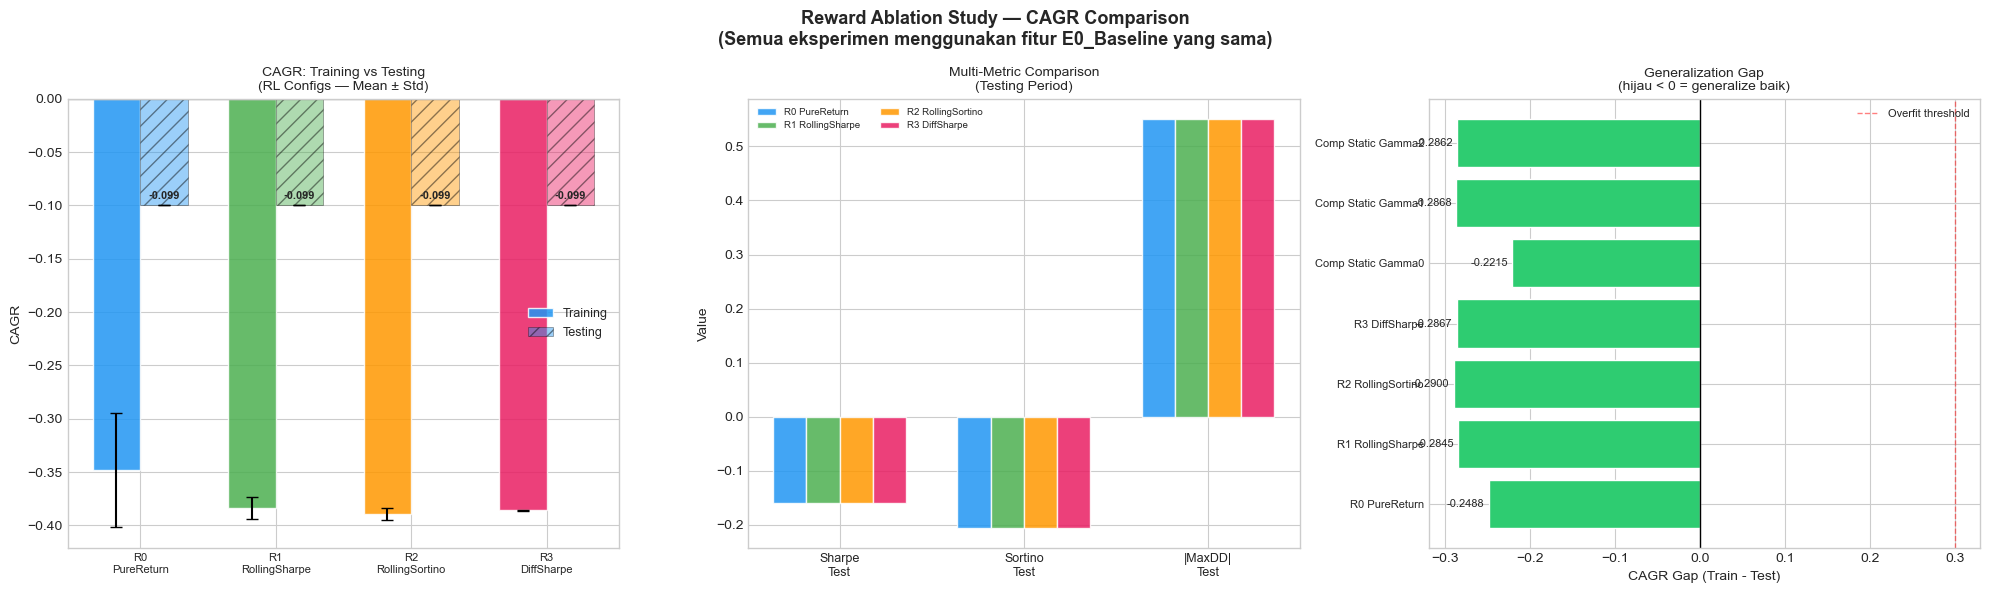

Saved: viz1_cagr_comparison.png


In [12]:
REWARD_COLORS = {
    'R0_PureReturn'      : '#2196F3',
    'R1_RollingSharpe'   : '#4CAF50',
    'R2_RollingSortino'  : '#FF9800',
    'R3_DiffSharpe'      : '#E91E63',
    'Comp_Static_Gamma0' : '#9E9E9E',
    'Comp_Static_Gamma1' : '#795548',
    'Comp_Static_Gamma2' : '#607D8B',
}

rl_ids     = list(REWARD_CONFIGS.keys())
static_ids = list(STATIC_BENCHMARKS.keys())

# ================================================================
# VIZ 1: Grouped bar — CAGR Train vs Test
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Reward Ablation Study — CAGR Comparison\n'
             '(Semua eksperimen menggunakan fitur E0_Baseline yang sama)',
             fontsize=13, fontweight='bold')

# Panel 1: CAGR Train vs Test (RL only)
ax1 = axes[0]
x = np.arange(len(rl_ids))
w = 0.35
train_vals = summary_df.loc[rl_ids, 'CAGR Train (mean)'].values
train_errs = summary_df.loc[rl_ids, 'CAGR Train (std)'].values
test_vals  = summary_df.loc[rl_ids, 'CAGR Test (mean)'].values
test_errs  = summary_df.loc[rl_ids, 'CAGR Test (std)'].values
colors_rl  = [REWARD_COLORS[e] for e in rl_ids]

bars1 = ax1.bar(x - w/2, train_vals, w, yerr=train_errs, label='Training',
                color=colors_rl, alpha=0.85, capsize=4, edgecolor='white')
bars2 = ax1.bar(x + w/2, test_vals, w, yerr=test_errs, label='Testing',
                color=colors_rl, alpha=0.45, capsize=4,
                edgecolor='black', linewidth=0.5, hatch='//')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels([e.replace('_', '\n') for e in rl_ids], fontsize=8)
ax1.set_ylabel('CAGR')
ax1.set_title('CAGR: Training vs Testing\n(RL Configs — Mean ± Std)', fontsize=10)
ax1.legend(fontsize=9)
for b, v in zip(bars2, test_vals):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
             f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')

# Panel 2: 3-metric radar-style bar (Sharpe, Sortino, |MaxDD|) — Testing
ax2 = axes[1]
metric_labels = ['Sharpe\nTest', 'Sortino\nTest', '|MaxDD|\nTest']
bar_w = 0.18
for i, exp_id in enumerate(rl_ids):
    vals = [
        summary_df.loc[exp_id, 'Sharpe Test'],
        summary_df.loc[exp_id, 'Sortino Test'],
        abs(summary_df.loc[exp_id, 'MaxDD Test']),
    ]
    positions = np.arange(3) + i * bar_w
    ax2.bar(positions, vals, bar_w,
            label=exp_id.replace('_', ' '), color=REWARD_COLORS[exp_id],
            alpha=0.85, edgecolor='white')
ax2.set_xticks(np.arange(3) + bar_w * (len(rl_ids)-1) / 2)
ax2.set_xticklabels(metric_labels, fontsize=9)
ax2.set_title('Multi-Metric Comparison\n(Testing Period)', fontsize=10)
ax2.legend(fontsize=7, ncol=2)
ax2.set_ylabel('Value')

# Panel 3: CAGR Gap (overfitting check)
ax3 = axes[2]
all_ids   = rl_ids + static_ids
gaps      = summary_df.loc[all_ids, 'CAGR Gap'].values
gap_colors = ['#e74c3c' if g > 0.3 else '#2ecc71' if g < 0 else '#f39c12' for g in gaps]
bars3 = ax3.barh([e.replace('_', ' ') for e in all_ids], gaps,
                 color=gap_colors, edgecolor='white')
ax3.axvline(0, color='black', linewidth=1)
ax3.axvline(0.3, color='red', linewidth=1, linestyle='--', alpha=0.5, label='Overfit threshold')
ax3.set_xlabel('CAGR Gap (Train - Test)')
ax3.set_title('Generalization Gap\n(hijau < 0 = generalize baik)', fontsize=10)
ax3.legend(fontsize=8)
for bar, g in zip(bars3, gaps):
    ax3.text(g + (0.005 if g >= 0 else -0.005),
             bar.get_y() + bar.get_height()/2,
             f'{g:+.4f}', va='center',
             ha='left' if g >= 0 else 'right', fontsize=8)
ax3.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('reward_ablation_results/viz1_cagr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz1_cagr_comparison.png')


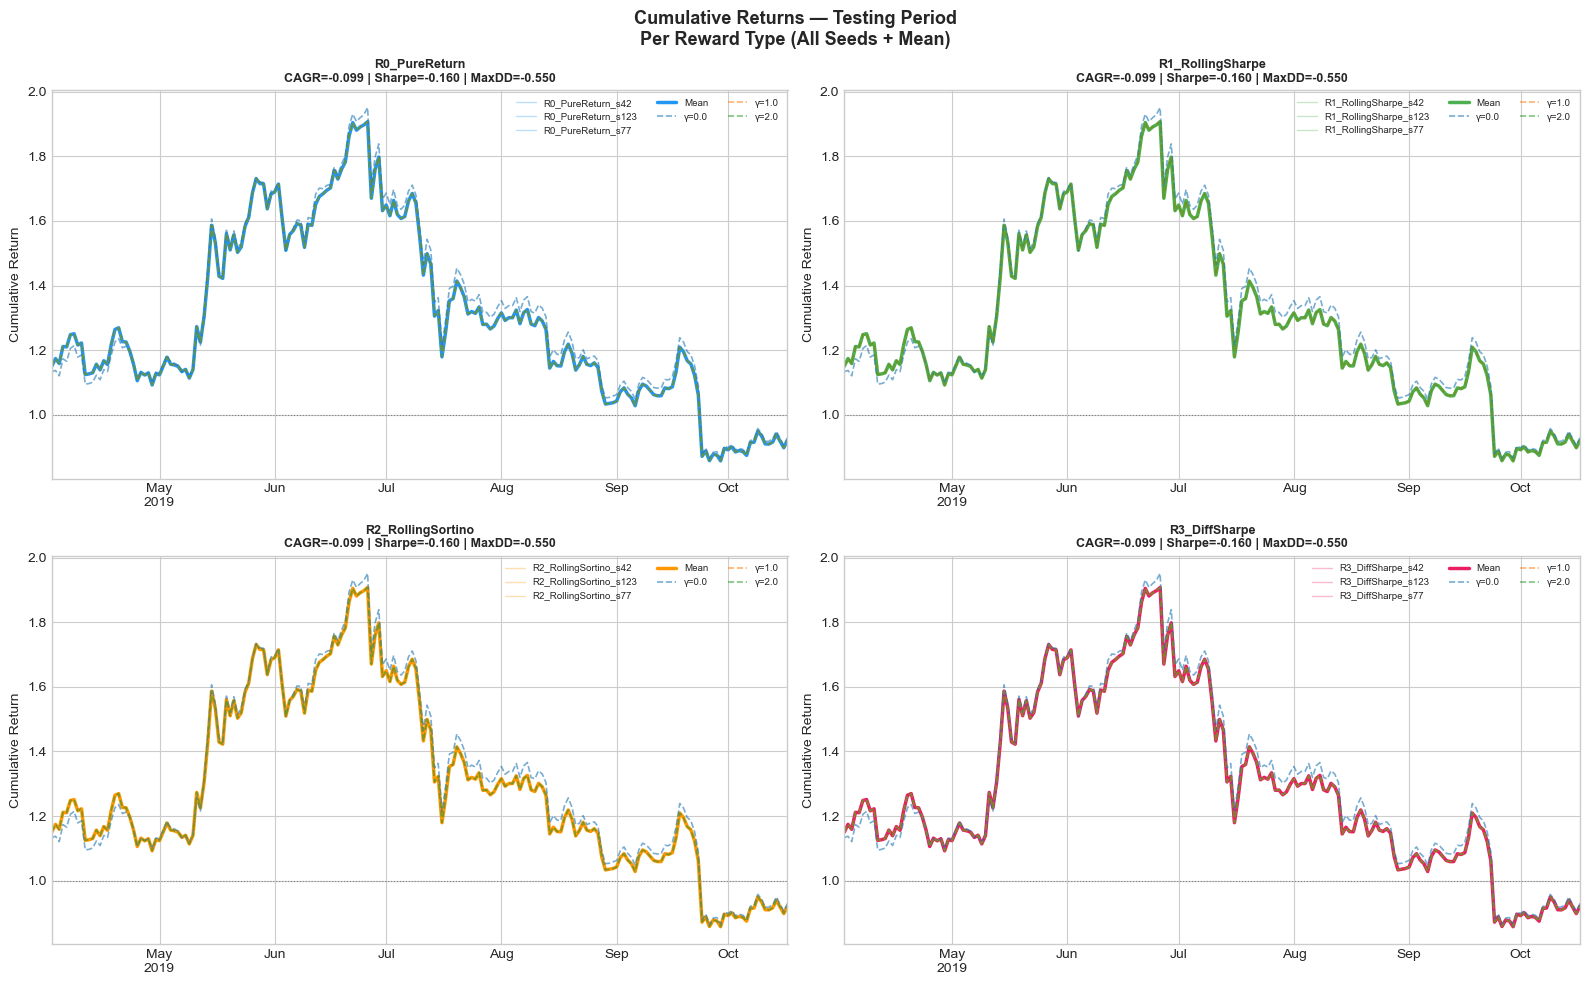

Saved: viz2_cumulative_returns.png


In [13]:
# ================================================================
# VIZ 2: Cumulative Returns — Testing (semua reward configs)
# ================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Cumulative Returns — Testing Period\nPer Reward Type (All Seeds + Mean)',
             fontsize=13, fontweight='bold')

for ax, exp_id in zip(axes.flatten(), rl_ids):
    color = REWARD_COLORS[exp_id]
    seed_cums = []
    for seed in SEEDS:
        ret = reward_results[exp_id]['test'][seed]
        cum = (1 + ret).cumprod()
        cum.plot(ax=ax, alpha=0.3, color=color, linewidth=1)
        seed_cums.append(cum)

    mean_cum = pd.concat(seed_cums, axis=1).mean(axis=1)
    mean_cum.plot(ax=ax, color=color, linewidth=2.5, label='Mean')

    # Static benchmark overlay
    for bench_id, gamma_val in STATIC_BENCHMARKS.items():
        bench_ret = reward_results[bench_id]['test'][SEEDS[0]]
        (1 + bench_ret).cumprod().plot(ax=ax, linestyle='--', alpha=0.6, linewidth=1.2,
                                        label=f'γ={gamma_val}')

    cagr = summary_df.loc[exp_id, 'CAGR Test (mean)']
    sh   = summary_df.loc[exp_id, 'Sharpe Test']
    mdd  = summary_df.loc[exp_id, 'MaxDD Test']
    ax.set_title(f'{exp_id}\nCAGR={cagr:.3f} | Sharpe={sh:.3f} | MaxDD={mdd:.3f}',
                 fontsize=9, fontweight='bold')
    ax.set_ylabel('Cumulative Return')
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)
    ax.legend(fontsize=7, ncol=3)

plt.tight_layout()
plt.savefig('reward_ablation_results/viz2_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz2_cumulative_returns.png')


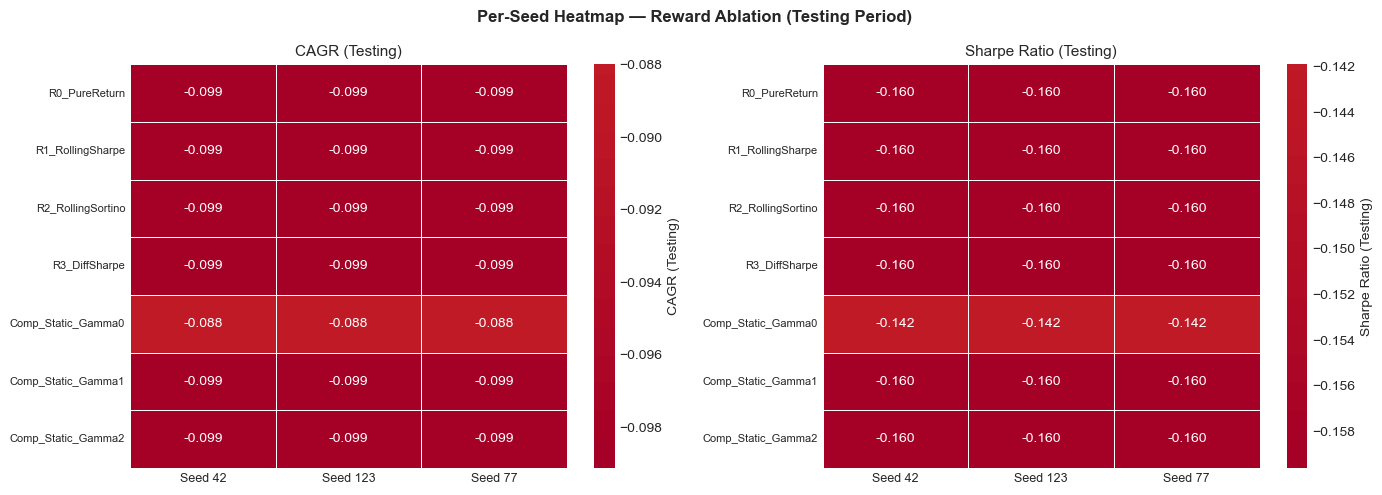

Saved: viz3_heatmap_perseed.png


In [14]:
# ================================================================
# VIZ 3: Per-Seed Heatmap — CAGR & Sharpe (Testing)
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Per-Seed Heatmap — Reward Ablation (Testing Period)',
             fontsize=12, fontweight='bold')

for metric, ax, title in [
    ('cagr', axes[0], 'CAGR (Testing)'),
    ('sharpe', axes[1], 'Sharpe Ratio (Testing)')
]:
    hm = pd.DataFrame(index=all_exp_ids, columns=[f'Seed {s}' for s in SEEDS], dtype=float)
    for exp_id in all_exp_ids:
        for seed in SEEDS:
            ret = reward_results[exp_id]['test'][seed]
            val = (calculate_annualized_return(ret) if metric == 'cagr'
                   else calculate_metrics(ret)['Sharpe Ratio'])
            hm.loc[exp_id, f'Seed {seed}'] = val
    hm = hm.fillna(0).astype(float)
    sns.heatmap(hm, ax=ax, annot=True, fmt='.3f',
                cmap='RdYlGn', center=0, linewidths=0.5,
                cbar_kws={'label': title})
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='y', rotation=0, labelsize=8)
    ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('reward_ablation_results/viz3_heatmap_perseed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz3_heatmap_perseed.png')


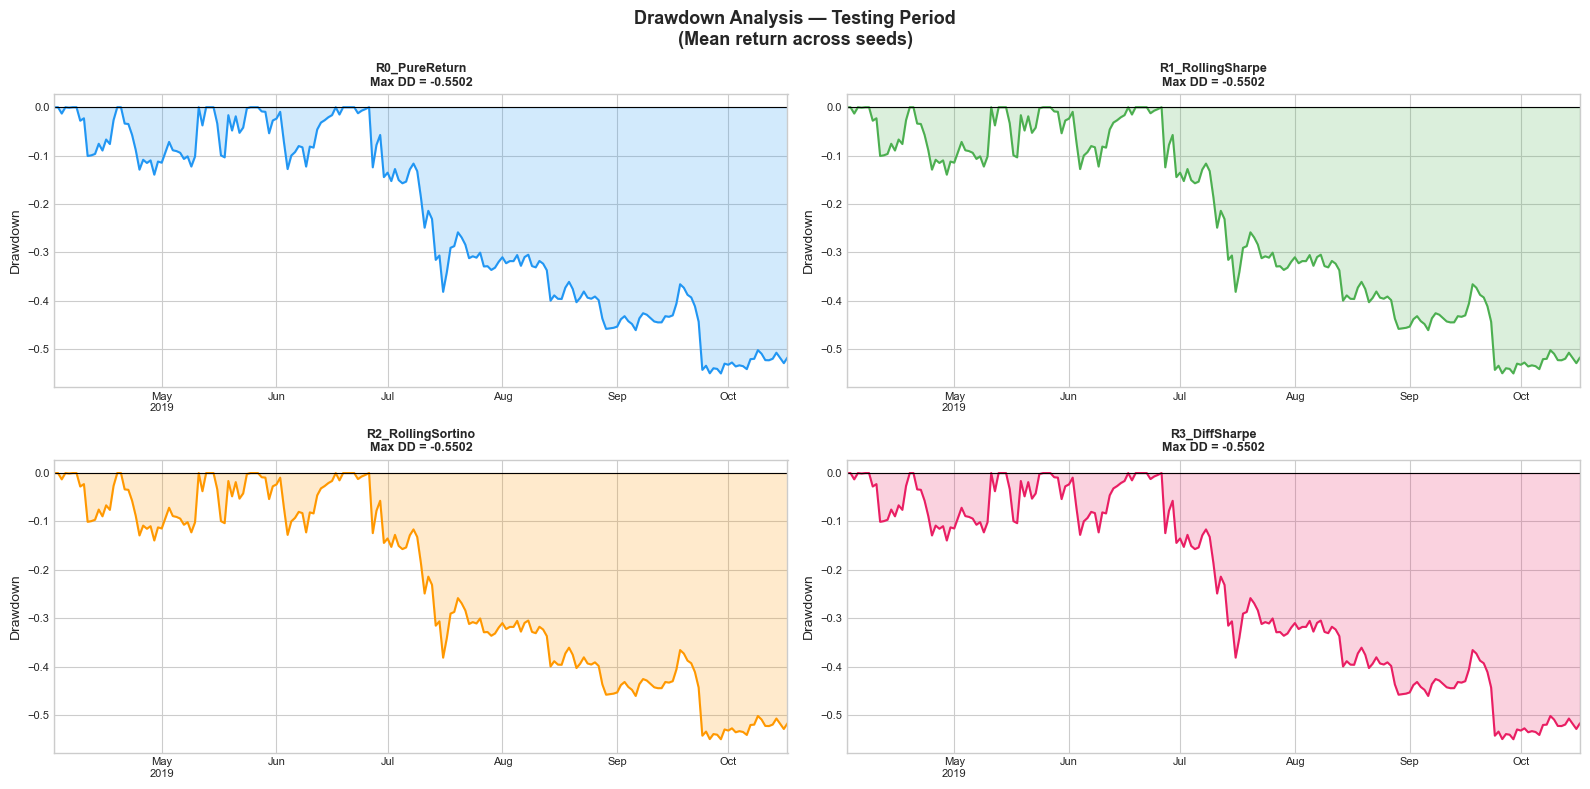

Saved: viz4_drawdown.png


In [15]:
# ================================================================
# VIZ 4: Drawdown Charts — Testing (mean across seeds)
# ================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Drawdown Analysis — Testing Period\n(Mean return across seeds)',
             fontsize=13, fontweight='bold')

for ax, exp_id in zip(axes.flatten(), rl_ids):
    color = REWARD_COLORS[exp_id]
    mean_ret = pd.concat(
        [reward_results[exp_id]['test'][s] for s in SEEDS], axis=1
    ).mean(axis=1)
    cum  = (1 + mean_ret).cumprod()
    peak = cum.expanding().max()
    dd   = (cum - peak) / peak

    dd.plot(ax=ax, color=color, linewidth=1.5)
    ax.fill_between(dd.index, dd.values, 0, color=color, alpha=0.2)
    ax.axhline(0, color='black', linewidth=0.8)

    max_dd = dd.min()
    ax.set_title(f'{exp_id}\nMax DD = {max_dd:.4f}', fontsize=9, fontweight='bold')
    ax.set_ylabel('Drawdown')
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('reward_ablation_results/viz4_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz4_drawdown.png')


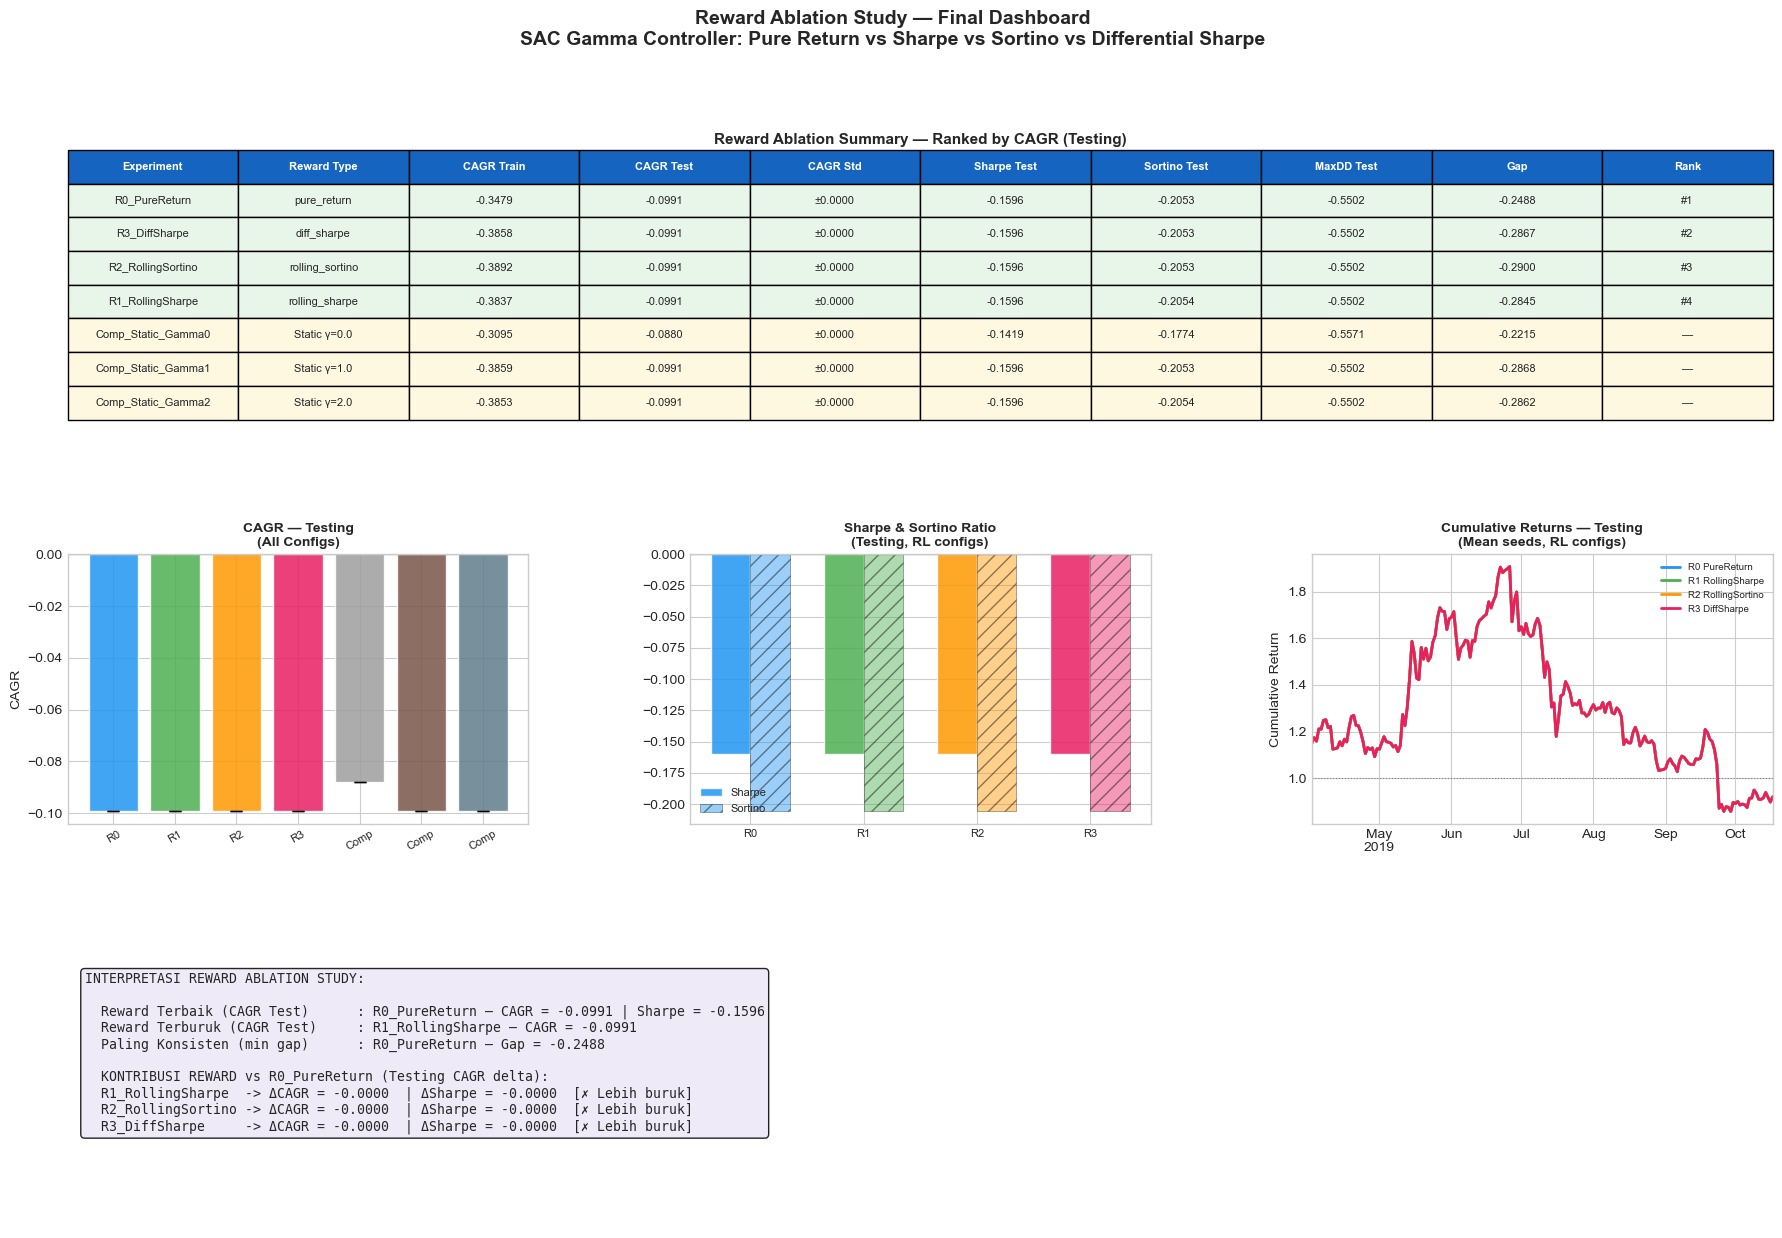


REWARD ABLATION STUDY COMPLETE
Outputs di: reward_ablation_results/
  - reward_ablation_summary.csv
  - viz1_cagr_comparison.png
  - viz2_cumulative_returns.png
  - viz3_heatmap_perseed.png
  - viz4_drawdown.png
  - viz5_final_dashboard.png


In [16]:
# ================================================================
# VIZ 5: Final Dashboard — Summary untuk Thesis
# ================================================================
fig = plt.figure(figsize=(22, 14))
fig.suptitle('Reward Ablation Study — Final Dashboard\n'
             'SAC Gamma Controller: Pure Return vs Sharpe vs Sortino vs Differential Sharpe',
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# --- Panel 1 (top, full width): Summary Table ---
ax_tbl = fig.add_subplot(gs[0, :])
ax_tbl.axis('off')

col_labels = ['Experiment', 'Reward Type',
              'CAGR Train', 'CAGR Test', 'CAGR Std',
              'Sharpe Test', 'Sortino Test', 'MaxDD Test', 'Gap', 'Rank']
tbl_data = []
ranked_rl = summary_df[summary_df['Type'] == 'RL'].sort_values('CAGR Test (mean)', ascending=False)
ranked_st = summary_df[summary_df['Type'] == 'Static'].sort_values('CAGR Test (mean)', ascending=False)
ranked_all = pd.concat([ranked_rl, ranked_st])

for rank, (exp_id, row) in enumerate(ranked_all.iterrows(), 1):
    rank_str = f'#{rank}' if row['Type'] == 'RL' else '—'
    tbl_data.append([
        exp_id,
        row['Reward Type'],
        f"{row['CAGR Train (mean)']:+.4f}",
        f"{row['CAGR Test (mean)']:+.4f}",
        f"±{row['CAGR Test (std)']:.4f}",
        f"{row['Sharpe Test']:+.4f}",
        f"{row['Sortino Test']:+.4f}",
        f"{row['MaxDD Test']:.4f}",
        f"{row['CAGR Gap']:+.4f}",
        rank_str,
    ])

tbl = ax_tbl.table(cellText=tbl_data, colLabels=col_labels,
                   cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#1565C0')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i, (exp_id, row) in enumerate(ranked_all.iterrows(), 1):
    fc = '#E8F5E9' if row['Type'] == 'RL' else '#FFF8E1'
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor(fc)
ax_tbl.set_title('Reward Ablation Summary — Ranked by CAGR (Testing)',
                 fontsize=11, fontweight='bold', pad=4)

# --- Panel 2 (mid-left): CAGR Test bar ---
ax2 = fig.add_subplot(gs[1, 0])
cagr_vals = summary_df.loc[all_exp_ids, 'CAGR Test (mean)'].values
cagr_errs = summary_df.loc[all_exp_ids, 'CAGR Test (std)'].values
bar_colors = [REWARD_COLORS[e] for e in all_exp_ids]
ax2.bar(range(len(all_exp_ids)), cagr_vals, yerr=cagr_errs,
        color=bar_colors, edgecolor='white', capsize=4, alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(range(len(all_exp_ids)))
ax2.set_xticklabels([e.split('_')[0] for e in all_exp_ids], fontsize=8, rotation=30)
ax2.set_ylabel('CAGR')
ax2.set_title('CAGR — Testing\n(All Configs)', fontsize=10, fontweight='bold')

# --- Panel 3 (mid-center): Sharpe & Sortino Test ---
ax3 = fig.add_subplot(gs[1, 1])
bw = 0.35
x3 = np.arange(len(rl_ids))
sh_vals = summary_df.loc[rl_ids, 'Sharpe Test'].values
so_vals = summary_df.loc[rl_ids, 'Sortino Test'].values
ax3.bar(x3 - bw/2, sh_vals, bw, label='Sharpe', color=[REWARD_COLORS[e] for e in rl_ids],
        alpha=0.85, edgecolor='white')
ax3.bar(x3 + bw/2, so_vals, bw, label='Sortino', color=[REWARD_COLORS[e] for e in rl_ids],
        alpha=0.45, edgecolor='black', linewidth=0.5, hatch='//')
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_xticks(x3)
ax3.set_xticklabels([e.split('_')[0] for e in rl_ids], fontsize=8)
ax3.set_title('Sharpe & Sortino Ratio\n(Testing, RL configs)', fontsize=10, fontweight='bold')
ax3.legend(fontsize=8)

# --- Panel 4 (mid-right): Cumulative Returns overlay ---
ax4 = fig.add_subplot(gs[1, 2])
for exp_id in rl_ids:
    mean_ret = pd.concat(
        [reward_results[exp_id]['test'][s] for s in SEEDS], axis=1
    ).mean(axis=1)
    (1 + mean_ret).cumprod().plot(
        ax=ax4, label=exp_id.replace('_', ' '),
        color=REWARD_COLORS[exp_id], linewidth=2)
ax4.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)
ax4.set_title('Cumulative Returns — Testing\n(Mean seeds, RL configs)', fontsize=10, fontweight='bold')
ax4.legend(fontsize=7)
ax4.set_ylabel('Cumulative Return')

# --- Panel 5 (bottom, full): Interpretasi otomatis ---
ax5 = fig.add_subplot(gs[2, :])
ax5.axis('off')

best_rl  = ranked_rl.index[0]
worst_rl = ranked_rl.index[-1]
best_gap = summary_df.loc[rl_ids, 'CAGR Gap'].abs().idxmin()

def delta_vs_r0(exp_id, col='CAGR Test (mean)'):
    return summary_df.loc[exp_id, col] - summary_df.loc['R0_PureReturn', col]

txt = (
    "INTERPRETASI REWARD ABLATION STUDY:\n\n"
    f"  Reward Terbaik (CAGR Test)      : {best_rl}"
    f" — CAGR = {summary_df.loc[best_rl, 'CAGR Test (mean)']:.4f}"
    f" | Sharpe = {summary_df.loc[best_rl, 'Sharpe Test']:.4f}\n"
    f"  Reward Terburuk (CAGR Test)     : {worst_rl}"
    f" — CAGR = {summary_df.loc[worst_rl, 'CAGR Test (mean)']:.4f}\n"
    f"  Paling Konsisten (min gap)      : {best_gap}"
    f" — Gap = {summary_df.loc[best_gap, 'CAGR Gap']:+.4f}\n\n"
    "  KONTRIBUSI REWARD vs R0_PureReturn (Testing CAGR delta):\n"
    f"  R1_RollingSharpe  -> ΔCAGR = {delta_vs_r0('R1_RollingSharpe'):+.4f}"
    f"  | ΔSharpe = {delta_vs_r0('R1_RollingSharpe', 'Sharpe Test'):+.4f}"
    f"  {'[✓ Lebih baik]' if delta_vs_r0('R1_RollingSharpe') > 0 else '[✗ Lebih buruk]'}\n"
    f"  R2_RollingSortino -> ΔCAGR = {delta_vs_r0('R2_RollingSortino'):+.4f}"
    f"  | ΔSharpe = {delta_vs_r0('R2_RollingSortino', 'Sharpe Test'):+.4f}"
    f"  {'[✓ Lebih baik]' if delta_vs_r0('R2_RollingSortino') > 0 else '[✗ Lebih buruk]'}\n"
    f"  R3_DiffSharpe     -> ΔCAGR = {delta_vs_r0('R3_DiffSharpe'):+.4f}"
    f"  | ΔSharpe = {delta_vs_r0('R3_DiffSharpe', 'Sharpe Test'):+.4f}"
    f"  {'[✓ Lebih baik]' if delta_vs_r0('R3_DiffSharpe') > 0 else '[✗ Lebih buruk]'}"
)
ax5.text(0.01, 0.95, txt, transform=ax5.transAxes,
         fontsize=9.5, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#EDE7F6', alpha=0.85))

plt.savefig('reward_ablation_results/viz5_final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*60)
print('REWARD ABLATION STUDY COMPLETE')
print('='*60)
print('Outputs di: reward_ablation_results/')
print('  - reward_ablation_summary.csv')
print('  - viz1_cagr_comparison.png')
print('  - viz2_cumulative_returns.png')
print('  - viz3_heatmap_perseed.png')
print('  - viz4_drawdown.png')
print('  - viz5_final_dashboard.png')
